In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("data/car_ownership.csv")
df.sample(5)

,monthly_salary,owns_car
5,56000,1
15,55000,1
20,21000,0
17,58000,1
23,45000,1


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [4]:
x_train,x_test,y_train,y_test=train_test_split(df[['monthly_salary']],df['owns_car'],test_size=0.2,random_state=42)

In [5]:
model=LogisticRegression()
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
model.predict([[2000]])

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [7]:
model.predict_proba(x_test)

array([[0.05404093, 0.94595907],
       [0.70600413, 0.29399587],
       [0.06013358, 0.93986642],
       [0.77134478, 0.22865522],
       [0.84145222, 0.15854778],
       [0.72895826, 0.27104174]])

In [8]:
model.score(x_test,y_test)

1.0

In [9]:
x = x_test.to_numpy().tolist()

In [10]:
import math
def sigmoid(x):
    return 1/(1+math.exp(-x)) #returns any values in an range of 0 to 1


In [11]:
def prediction(salary, model):
    z = model.coef_.item() * salary + model.intercept_.item()
    return sigmoid(z)

In [12]:
prediction(60000,model) # any probability more then 0.5 is 1, if less the 0.5 then 0

0.9331354243314959

In [13]:
x_range=np.linspace(df['monthly_salary'].min(),df['monthly_salary'].max(),300).reshape(-1,1)

In [14]:
y_prob = model.predict_proba(x_range)[:, 1]

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


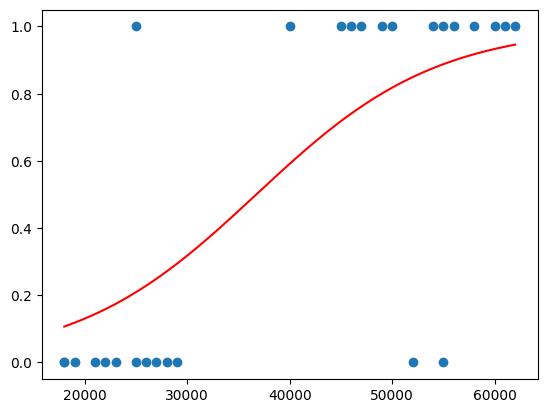

In [15]:
import matplotlib.pyplot as plt
plt.scatter(df['monthly_salary'],df['owns_car'])
plt.plot(x_range, y_prob,color='r', label='Predicted')

In [19]:
y_pred=model.predict(x_test)

In [21]:
y_test.tolist()

[1, 0, 1, 0, 0, 0]

<h1>accuracy</h1>

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



<h1>confusion matrix

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [26]:
cm=confusion_matrix(y_test, y_pred)
cm

array([[4, 0],
       [0, 2]])

<Axes: >

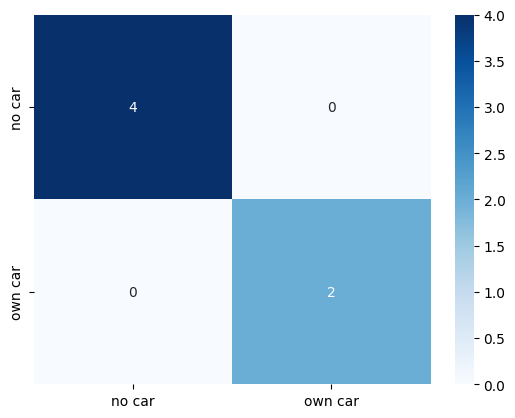

In [30]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=['no car','own car'],yticklabels=['no car','own car'])